In [1]:
#Task 1.1 Variable Roles and Data Types
import pandas as pd
import numpy as np

df = pd.read_csv('dataset_ifn580_262_v1.csv')

columns_to_check = [
    'destination',
    'passanger',
    'weather',
    'coupon',
    'expiration',
    'gender',
    'maritalStatus',
    'education',
    'occupation'
]

for col in columns_to_check:
    print(col, ":", df[col].unique())

destination : ['No Urgent Place' 'Home' 'Work']
passanger : ['Alone' 'Friend(s)' 'Kid(s)' 'Partner']
weather : ['Sunny' 'Rainy' 'Snowy']
coupon : ['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']
expiration : ['1d' '2h']
gender : ['Female' 'Male']
maritalStatus : ['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
education : ['Some college - no degree' 'Bachelors degree' 'Associates degree'
 'High School Graduate' 'Graduate degree (Masters or Doctorate)'
 'Some High School']
occupation : ['Unemployed' 'Architecture & Engineering' 'Student'
 'Education&Training&Library' 'Healthcare Support'
 'Healthcare Practitioners & Technical' 'Sales & Related' 'Management'
 'Arts Design Entertainment Sports & Media' 'Computer & Mathematical'
 'Life Physical Social Science' 'Personal Care & Service'
 'Community & Social Services' 'Office & Administrative Support'
 'Construction & Extraction' 'Legal' 'Retired'
 'Installation Maintenance & Repair' 

# Missing Value

- 'car' has approximately 99.15% missing values and may be unreliable for modelling.
- 'temperature' has a small proportion of missing values.
- 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', and 'Restaurant20To50' also have small proportions of missing values.
- The restaurant/visit-frequency variables contain ordered categories, so they should be treated as ordinal rather than nominal.

'Temperture' float64/ 1.970987 [55. 80. nan 30.]

'Bar' object/ 0.843582 

'Coffeehouse' object/ 1.710817

'Carryaway' object/ 1.190476

'RestaurantLessThan20' object/ 1.024913

'Restaurant20To50' object/ 1.490066

# Data exploration

Age:
[21, 46, 26, 31, 41, 50plus, 36, below21]
- object in pandas
- contains numeric categories plus textual boundaries such as below21 / 50plus
- ordered meaning
- likely ordinal

income:
[$37500-$49999, $62500-$74999, $12500-$24999, $75000-$87499, $50000-$62499, $25000-$37499, $100000 or more, $87500-$99999, less than $12500]
- object in pandas
- income range represented as text
- ordered meaning
- likely ordinal

time:
[2PM, 10AM, 6PM, 7AM, 10PM]
- object in pandas
- clock time represented as text with AM/PM
- requires numerical/ordered representation before modelling

In [2]:
# Task 1.2 Data Quality, Cleaning and Preprocessing
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percent
})

missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

display(missing_summary)

,Missing Count,Missing Percentage
temperature,250,1.970987
car,12576,99.148534
Bar,107,0.843582
CoffeeHouse,217,1.710817
CarryAway,151,1.190476
RestaurantLessThan20,130,1.024913
Restaurant20To50,189,1.490066


Car:
- missing rate> 99%
- too little observed information
- Impuation would be unreliable
- Remove the variable

In [3]:
print("Mean:", df['temperature'].mean())
print("Median:", df['temperature'].median())

Mean: 63.28976998552356
Median: 80.0


Temperature:
- has 250 missing values, which is a relatively small proportion of the dataset.
- The mean is 63.289, while the median is 80.
- The original temperature values are 30, 55, and 80.
- Median imputation is selected because it keeps the imputed value within the existing temperature values and avoids introducing a new value that does not appear in the original dataset.

In [4]:
print(df['Bar'].value_counts(dropna=False))

Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
NaN       107
Name: count, dtype: int64


Bar:
- has 107 missing values, which is a small proportion of the dataset.
- The variable contains ordered frequency categories such as never, less1, 1~3, 4~8, and gt8.
- The most frequent category is never
- Mode imputation is selected because the variable is categorical and the missing proportion is low.

In [5]:
print(df['CoffeeHouse'].value_counts(dropna=False))

CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
NaN       217
Name: count, dtype: int64


CoffeeHouse:
- has 217 missing values, which is a small proportion of the dataset.
- The variable contains ordered frequency categories such as never, less1, 1~3, 4~8, and gt8.
- The most frequent category is less1
- Mode imputation is selected because the variable is categorical and the missing proportion is low.

In [6]:
print(df['CarryAway'].value_counts(dropna=False))

CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
NaN       151
Name: count, dtype: int64


CarryAway:
- has 151 missing values, which is a small proportion of the dataset.
- The variable contains ordered frequency categories such as never, less1, 1~3, 4~8, and gt8.
- The most frequent category is 1~3.
- Mode imputation is selected because the variable is categorical and the missing proportion is low.

In [7]:
print(df['RestaurantLessThan20'].value_counts(dropna=False))

RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
NaN       130
Name: count, dtype: int64


RestaurantLessThan20:
- has 130 missing values, which is a small proportion of the dataset.
- The variable contains ordered frequency categories such as never, less1, 1~3, 4~8, and gt8.
- The most frequent category is 1~3.
- Mode imputation is selected because the variable is categorical and the missing proportion is low.

In [8]:
print(df['Restaurant20To50'].value_counts(dropna=False))

Restaurant20To50
less1    6077
1~3      3290
never    2136
4~8       728
gt8       264
NaN       189
Name: count, dtype: int64


Restaurant20To50:
- has 189 missing values, which is a small proportion of the dataset.
- The variable contains ordered frequency categories such as never, less1, 1~3, 4~8, and gt8.
- The most frequent category is less1.
- Mode imputation is selected because the variable is categorical and the missing proportion is low.

In [9]:
# Task 1.3 Mixed Numerical/Textual Representation and Time

df = df.drop(columns=['car'])
df['temperature'] = df['temperature'].fillna(df['temperature'].median())
df['Bar'] = df['Bar'].fillna(df['Bar'].mode()[0])
df['CoffeeHouse'] = df['CoffeeHouse'].fillna(df['CoffeeHouse'].mode()[0])
df['CarryAway'] = df['CarryAway'].fillna(df['CarryAway'].mode()[0])
df['RestaurantLessThan20'] = df['RestaurantLessThan20'].fillna(df['RestaurantLessThan20'].mode()[0])
df['Restaurant20To50'] = df['Restaurant20To50'].fillna(df['Restaurant20To50'].mode()[0])

df.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
is_accepted             0
dtype: int64

In [10]:
# encoding(maping)
age_mapping = {
    'below21': 0,
    '21':1,
    '26':2,
    '31':3,
    '36':4,
    '41':5,
    '46':6,
    '50plus': 7
}
df['age'] = df['age'].map(age_mapping)

In [11]:
df['age'].unique()

array([1, 6, 2, 3, 5, 7, 4, 0], dtype=int64)

In [12]:
df['age'].isnull().sum()

0

In [13]:
time_mapping = {
    '7AM': 0,
    '10AM': 1,
    '2PM': 2,
    '6PM': 3,
    '10PM': 4
}
df['time'] = df['time'].map(time_mapping)

# Time Encoding

- The 'time' variable has a natural chronological order during the day.
- The categories were manually ordered from the earliest to the latest time.
- Consecutive integers were used to preserve this order in a numerical form.
- These encoded values represent ordinal positions only and do not represent the actual time intervals between categories.ies.

In [14]:
df['time'].unique()

array([2, 1, 3, 0, 4], dtype=int64)

In [15]:
df['time'].isnull().sum()

0

In [16]:
income_mapping = {
    'Less than $12500': 0,
    '$12500 - $24999': 1,
    '$25000 - $37499': 2,
    '$37500 - $49999': 3,
    '$50000 - $62499': 4,
    '$62500 - $74999': 5,
    '$75000 - $87499': 6,
    '$87500 - $99999': 7,
    '$100000 or More': 8
}
df['income'] = df['income'].map(income_mapping)

In [17]:
df['income'].unique()

array([3, 5, 1, 6, 4, 2, 8, 7, 0], dtype=int64)

In [18]:
df['income'].isnull().sum()

0

In [19]:
df['education'].unique()

array(['Some college - no degree', 'Bachelors degree',
       'Associates degree', 'High School Graduate',
       'Graduate degree (Masters or Doctorate)', 'Some High School'],
      dtype=object)

In [20]:
education_mapping = {
    'Some High School': 0,
    'High School Graduate': 1,
    'Some college - no degree': 2,
    'Associates degree': 3,
    'Bachelors degree': 4,
    'Graduate degree (Masters or Doctorate)': 5
}
df['education'] = df['education'].map(education_mapping)

In [21]:
df['education'].unique()

array([2, 4, 3, 1, 5, 0], dtype=int64)

In [22]:
df['education'].isnull().sum()

0

In [23]:
frequency_mapping = {
    'never': 0,
    'less1': 1,
    '1~3': 2,
    '4~8': 3,
    'gt8': 4
}
frequency_columns = [
    'Bar',
    'CoffeeHouse',
    'CarryAway',
    'RestaurantLessThan20',
    'Restaurant20To50'
]

for col in frequency_columns:
    df[col] = df[col].map(frequency_mapping)

In [24]:
df[frequency_columns].isnull().sum()

Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
dtype: int64

In [25]:
for col in frequency_columns:
    print(col, df[col].unique())

Bar [0 1 2 4 3]
CoffeeHouse [0 1 3 2 4]
CarryAway [2 3 4 1 0]
RestaurantLessThan20 [3 2 1 4 0]
Restaurant20To50 [2 1 0 4 3]


In [26]:
expiration_mapping = {
    '2h': 0,
    '1d': 1
}
df['expiration'] = df['expiration'].map(expiration_mapping)

In [27]:
df['expiration'].unique()

array([1, 0], dtype=int64)

In [28]:
df['expiration'].isnull().sum()

0

In [29]:
gender_mapping = {
    'Female': 0,
    'Male': 1
}
df['gender'] = df['gender'].map(gender_mapping)

In [30]:
df['gender'].unique()

array([0, 1], dtype=int64)

In [31]:
# saving for later
df_copy = df

In [32]:
destination_encoded = pd.get_dummies(
    df['destination'],
    prefix='destination',
    dtype=int
)

# Nominal Variable Encoding

- 'destination' is a nominal categorical variable with no natural order.
- One-hot encoding is used to convert the categories into numerical binary variables.
- Each category is represented by a separate 0/1 column.

In [33]:
destination_encoded.head()

,destination_Home,destination_No Urgent Place,destination_Work
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


In [34]:
df = pd.concat([df, destination_encoded], axis=1)

In [35]:
df = df.drop(columns=['destination'])

In [36]:
df.head()

,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,...,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,is_accepted,destination_Home,destination_No Urgent Place,destination_Work
0,Alone,Sunny,55.0,2,Restaurant(<20),1,0,1,Unmarried partner,1,...,2,1,0,0,0,1,1,0,1,0
1,Friend(s),Sunny,80.0,1,Coffee House,0,0,1,Unmarried partner,1,...,2,1,0,0,0,1,0,0,1,0
2,Friend(s),Sunny,80.0,1,Carry out & Take away,0,0,1,Unmarried partner,1,...,2,1,1,0,0,1,1,0,1,0
3,Friend(s),Sunny,80.0,2,Coffee House,0,0,1,Unmarried partner,1,...,2,1,1,0,0,1,0,0,1,0
4,Friend(s),Sunny,80.0,2,Coffee House,1,0,1,Unmarried partner,1,...,2,1,1,0,0,1,0,0,1,0


In [37]:
nominal_columns = [
    'passanger',
    'weather',
    'coupon',
    'maritalStatus',
    'occupation'
]
nominal_encoded = pd.get_dummies(
    df[nominal_columns],
    prefix=nominal_columns,
    dtype=int
)
df = pd.concat([df, nominal_encoded], axis=1)

In [38]:
df = df.drop(columns=nominal_columns)

In [39]:
df.head()

,temperature,time,expiration,gender,age,has_children,education,income,Bar,CoffeeHouse,...,occupation_Management,occupation_Office & Administrative Support,occupation_Personal Care & Service,occupation_Production Occupations,occupation_Protective Service,occupation_Retired,occupation_Sales & Related,occupation_Student,occupation_Transportation & Material Moving,occupation_Unemployed
0,55.0,2,1,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1
1,80.0,1,0,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1
2,80.0,1,0,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1
3,80.0,2,0,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1
4,80.0,2,1,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1


In [40]:
df.dtypes

temperature                                    float64
time                                             int64
expiration                                       int64
gender                                           int64
age                                              int64
                                                ...   
occupation_Retired                               int32
occupation_Sales & Related                       int32
occupation_Student                               int32
occupation_Transportation & Material Moving      int32
occupation_Unemployed                            int32
Length: 64, dtype: object

# checking Object

- 'df.select_dtypes(include='object').columns' was used to check whether any text-based columns remained after encoding.
- No 'object' columns remain.
- 'df.isnull().sum().sum()' was used to check the total number of missing values in the processed dataset.
- The result was 0, confirming that no missing values remain.

In [41]:
# Task 1.4 – Correlation Analysis and Redundant Variables

df.select_dtypes(exclude='number').columns

Index([], dtype='object')

In [42]:
df.dtypes[df.dtypes == 'object']

Series([], dtype: object)

In [43]:
correlation_matrix = df.corr()

In [44]:
correlation_matrix

,temperature,time,expiration,gender,age,has_children,education,income,Bar,CoffeeHouse,...,occupation_Management,occupation_Office & Administrative Support,occupation_Personal Care & Service,occupation_Production Occupations,occupation_Protective Service,occupation_Retired,occupation_Sales & Related,occupation_Student,occupation_Transportation & Material Moving,occupation_Unemployed
temperature,1.000000,-0.035530,-0.121833,-0.025419,-0.017893,-0.019894,0.008683,-0.029969,-0.005448,-0.016049,...,0.040296,-0.019941,-0.003830,-0.001028,0.022685,0.021477,-0.003243,0.022421,0.002254,-0.029577
time,-0.035530,1.000000,-0.030381,-0.003593,0.005114,0.026883,0.009751,0.010860,-0.014447,-0.000058,...,-0.020176,0.001148,0.003669,0.007005,-0.010955,-0.013038,0.000643,-0.008162,0.000166,0.019036
expiration,-0.121833,-0.030381,1.000000,0.001264,-0.021208,-0.016020,-0.016356,-0.020606,-0.009821,-0.002195,...,-0.014373,0.025240,-0.003858,0.017989,-0.007942,-0.007158,-0.002287,0.016554,0.000155,0.008767
gender,-0.025419,-0.003593,0.001264,1.000000,-0.099847,-0.159956,-0.004301,0.101738,0.161595,-0.044470,...,0.088371,-0.097346,-0.027272,0.058632,0.033578,0.013924,0.057932,0.092138,0.055712,-0.137959
age,-0.017893,0.005114,-0.021208,-0.099847,1.000000,0.442096,0.158249,0.084885,-0.158573,-0.049766,...,0.060981,0.025226,0.110139,0.067808,0.021135,0.313798,-0.000859,-0.396503,0.075858,-0.082651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
occupation_Retired,0.021477,-0.013038,-0.007158,0.013924,0.313798,0.114056,0.051814,-0.002094,-0.132851,-0.085394,...,-0.053599,-0.046416,-0.023836,-0.018849,-0.023836,1.000000,-0.061883,-0.076126,-0.026649,-0.083800
occupation_Sales & Related,-0.003243,0.000643,-0.002287,0.057932,-0.000859,-0.046576,-0.032885,-0.063590,-0.009931,-0.050215,...,-0.081674,-0.070729,-0.036321,-0.028722,-0.036321,-0.061883,1.000000,-0.116002,-0.040608,-0.127696
occupation_Student,0.022421,-0.008162,0.016554,0.092138,-0.396503,-0.222232,-0.145635,-0.117955,-0.021115,0.125814,...,-0.100474,-0.087009,-0.044681,-0.035333,-0.044681,-0.076126,-0.116002,1.000000,-0.049955,-0.157088
occupation_Transportation & Material Moving,0.002254,0.000166,0.000155,0.055712,0.075858,0.048911,-0.066045,-0.002199,0.009791,-0.007444,...,-0.035172,-0.030459,-0.015641,-0.012369,-0.015641,-0.026649,-0.040608,-0.049955,1.000000,-0.054991


In [45]:
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        corr_value = correlation_matrix.iloc[i, j]

        if abs(corr_value) > 0.90:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_value
            ))

high_corr_pairs

[('direction_opp', 'direction_same', -1.0)]

# remove direction_opp

- direction_same and direction_opp are perfectly negatively correlated (r = -1.0).
- Both variables contain redundant information.
- direction_same is retained because it is more directly interpretable.
- direction_opp is removed.

In [46]:
df = df.drop(columns=['direction_opp'])

In [47]:
correlation_matrix = df.corr()

In [48]:
'direction_opp' in df.columns

False

# Task 2 – Decision Tree

In [49]:
# Task 2.1 – Default Decision Tree
X = df.drop(columns=['is_accepted'])
y = df['is_accepted']

# Train-Test Split
The processed dataset was divided into 70% training data and 30% testing data.

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [51]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8878, 62)
(3806, 62)
(8878,)
(3806,)


In [52]:
from sklearn.tree import DecisionTreeClassifier

# Default Decision Tree Model
A default Decision Tree classifier was trained using the training dataset.

In [53]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [54]:
train_accuracy = dt_default.score(X_train, y_train)
test_accuracy = dt_default.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.9985357062401442
Test Accuracy: 0.6694692590646348


# Accuracy
- Training: 0.9985
- Testing: 0.6695
- large gap between training and testing
- possible overfitting

In [55]:
print("Number of Rules:", dt_default.get_n_leaves())

Number of Rules: 2290


In [56]:
from sklearn.tree import export_text

tree_rules = export_text(
    dt_default,
    feature_names=list(X.columns),
    max_depth=2
)

print(tree_rules)

|--- coupon_Carry out & Take away <= 0.50
|   |--- coupon_Restaurant(<20) <= 0.50
|   |   |--- CoffeeHouse <= 1.50
|   |   |   |--- truncated branch of depth 22
|   |   |--- CoffeeHouse >  1.50
|   |   |   |--- truncated branch of depth 23
|   |--- coupon_Restaurant(<20) >  0.50
|   |   |--- toCoupon_GEQ25min <= 0.50
|   |   |   |--- truncated branch of depth 21
|   |   |--- toCoupon_GEQ25min >  0.50
|   |   |   |--- truncated branch of depth 15
|--- coupon_Carry out & Take away >  0.50
|   |--- expiration <= 0.50
|   |   |--- temperature <= 42.50
|   |   |   |--- truncated branch of depth 16
|   |   |--- temperature >  42.50
|   |   |   |--- truncated branch of depth 27
|   |--- expiration >  0.50
|   |   |--- education <= 4.50
|   |   |   |--- truncated branch of depth 18
|   |   |--- education >  4.50
|   |   |   |--- truncated branch of depth 15



In [57]:
print("Tree Depth:", dt_default.get_depth())
print("Number of Nodes:", dt_default.tree_.node_count)

Tree Depth: 29
Number of Nodes: 4579


# First and Second Splits

- First split: 'coupon_Carry out & Take away'
- Second splits: 'coupon_Restaurant(<20)' and 'expiration'

# Tree Size
- Depth: 29
- Nodes: 4579
- Rules: 2290
- Large and deep tree
- likely overfitting

# Top 12 Important Variables


In [58]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_default.feature_importances_
})

top_12_features = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(12)

top_12_features

,Feature,Importance
7,income,0.071359
9,CoffeeHouse,0.064662
4,age,0.060753
8,Bar,0.049374
1,time,0.044157
10,CarryAway,0.043754
12,Restaurant20To50,0.043021
6,education,0.042308
31,coupon_Restaurant(<20),0.037414
11,RestaurantLessThan20,0.035487


# Default Model Parameters


In [59]:
dt_default.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 42,
 'splitter': 'best'}

# Default Parameters
- criterion: gini
- splitter: best
- max_depth: None
- min_samples_split: 2
- min_samples_leaf: 1

In [60]:
# Task 2.2 – Tuned Decision Tree with GridSearchCV
from sklearn.model_selection import GridSearchCV

# Parameter Grid
- For max_depth, I test values smaller than the default depth of 29 to restrict tree growth.
- Higher min_samples_split can stop the tree from creating splits that only involve very few samples.
- I increase min_samples_leaf values to prevent tiny leaf nodes, which is a common source of over‑fitting.
- Two split criteria, Gini and Entropy, are compared within this parameter search.

In [61]:
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}
dt_grid = DecisionTreeClassifier(random_state=42)

In [62]:
grid_search = GridSearchCV(
    estimator=dt_grid,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

In [63]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [64]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 20}
Best CV Score: 0.6911478238802182


In [65]:
dt_tuned = grid_search.best_estimator_

In [66]:
tuned_train_accuracy = dt_tuned.score(X_train, y_train)
tuned_test_accuracy = dt_tuned.score(X_test, y_test)

print("Tuned Training Accuracy:", tuned_train_accuracy)
print("Tuned Testing Accuracy:", tuned_test_accuracy)

Tuned Training Accuracy: 0.770218517684163
Tuned Testing Accuracy: 0.6981082501313716


# Best Parameters:
criterion = entropy

max_depth = 10

min_samples_leaf = 1

min_samples_split = 20

Best CV Score = 0.6911

Tuned Training Accuracy = 0.7702

Tuned Testing Accuracy = 0.6981

In [67]:
print("Tuned Tree Depth:", dt_tuned.get_depth())
print("Tuned Number of Nodes:", dt_tuned.tree_.node_count)
print("Tuned Number of Rules:", dt_tuned.get_n_leaves())

Tuned Tree Depth: 10
Tuned Number of Nodes: 647
Tuned Number of Rules: 324


In [68]:
tuned_tree_rules = export_text(
    dt_tuned,
    feature_names=list(X.columns),
    max_depth=2
)

print(tuned_tree_rules)

|--- coupon_Carry out & Take away <= 0.50
|   |--- coupon_Restaurant(<20) <= 0.50
|   |   |--- CoffeeHouse <= 1.50
|   |   |   |--- truncated branch of depth 8
|   |   |--- CoffeeHouse >  1.50
|   |   |   |--- truncated branch of depth 8
|   |--- coupon_Restaurant(<20) >  0.50
|   |   |--- toCoupon_GEQ25min <= 0.50
|   |   |   |--- truncated branch of depth 8
|   |   |--- toCoupon_GEQ25min >  0.50
|   |   |   |--- truncated branch of depth 8
|--- coupon_Carry out & Take away >  0.50
|   |--- expiration <= 0.50
|   |   |--- temperature <= 42.50
|   |   |   |--- truncated branch of depth 8
|   |   |--- temperature >  42.50
|   |   |   |--- truncated branch of depth 8
|   |--- expiration >  0.50
|   |   |--- education <= 3.50
|   |   |   |--- truncated branch of depth 8
|   |   |--- education >  3.50
|   |   |   |--- truncated branch of depth 8



# First and Second Splits

- First split: 'coupon_Carry out & Take away'
- Second splits: 'coupon_Restaurant(<20)' and 'expiration'

# Tuned Top 12 Important Variables

In [69]:
feature_importance_tuned = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_tuned.feature_importances_
})

top_12_features_tuned = feature_importance_tuned.sort_values(
    by='Importance',
    ascending=False
).head(12)

top_12_features_tuned

,Feature,Importance
9,CoffeeHouse,0.100909
31,coupon_Restaurant(<20),0.082108
28,coupon_Carry out & Take away,0.058340
2,expiration,0.057152
4,age,0.050888
7,income,0.050837
15,toCoupon_GEQ25min,0.047924
29,coupon_Coffee House,0.044665
8,Bar,0.044224
1,time,0.038083


# Comparison of Important Variables

In [70]:
df_default = top_12_features.copy()
df_tuned = top_12_features_tuned.copy()

df_default = df_default.rename(columns={"Importance":"Importance_Default"})
df_tuned = df_tuned.rename(columns={"Importance":"Importance_Tuned"})

df_compare = pd.merge(
    df_default,
    df_tuned,
    on="Feature",
    how="outer"
).sort_values("Importance_Tuned", ascending=False)

df_compare["In_Default_Top12"] = df_compare["Importance_Default"].notna()
df_compare["In_Tuned_Top12"] = df_compare["Importance_Tuned"].notna()
df_compare["Importance_Change"] = (df_compare["Importance_Tuned"] - df_compare["Importance_Default"])

display(df_compare)

,Feature,Importance_Default,Importance_Tuned,In_Default_Top12,In_Tuned_Top12,Importance_Change
1,CoffeeHouse,0.064662,0.100909,True,True,0.036248
8,coupon_Restaurant(<20),0.037414,0.082108,True,True,0.044694
12,coupon_Carry out & Take away,NaN,0.058340,False,True,NaN
13,expiration,NaN,0.057152,False,True,NaN
2,age,0.060753,0.050888,True,True,-0.009865
0,income,0.071359,0.050837,True,True,-0.020521
10,toCoupon_GEQ25min,0.030926,0.047924,True,True,0.016998
14,coupon_Coffee House,NaN,0.044665,False,True,NaN
3,Bar,0.049374,0.044224,True,True,-0.005150
4,time,0.044157,0.038083,True,True,-0.006074


In [71]:
# Task 2.3 ROC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [72]:
default_prob = dt_default.predict_proba(X_test)[:, 1]
tuned_prob = dt_tuned.predict_proba(X_test)[:, 1]

In [73]:
fpr_default, tpr_default, _ = roc_curve(y_test, default_prob)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, tuned_prob)

auc_default = roc_auc_score(y_test, default_prob)
auc_tuned = roc_auc_score(y_test, tuned_prob)

print("Default AUC:", auc_default)
print("Tuned AUC:", auc_tuned)

Default AUC: 0.6635839200110883
Tuned AUC: 0.7437721629523295


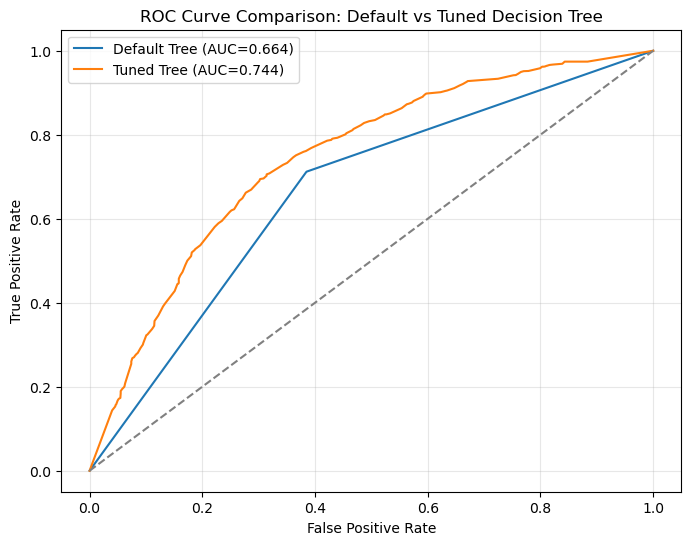

In [74]:
plt.figure(figsize=(8,6))

plt.plot(fpr_default, tpr_default,
         label=f"Default Tree (AUC={auc_default:.3f})")

plt.plot(fpr_tuned, tpr_tuned,
         label=f"Tuned Tree (AUC={auc_tuned:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Default vs Tuned Decision Tree")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ROC Observation
- Default AUC: 0.6636
- Tuned AUC: 0.7438
- Tuned tree performs better on ROC/AUC.

In [75]:
# Task 2.4 – Default vs Tuned Decision Tree Comparison

import time

start = time.time()

dt_default_time = DecisionTreeClassifier(random_state=42)
dt_default_time.fit(X_train, y_train)

end = time.time()

default_train_time = end - start
print(f"Default tree training time: {default_train_time:.4f} s")

Default tree training time: 0.0361 s


In [76]:
start = time.time()

grid_search.fit(X_train, y_train)

end = time.time()

grid_train_time = end - start
print(f"GridSearchCV training time: {grid_train_time:.4f} s")

GridSearchCV training time: 14.4491 s


In [77]:
import time

start = time.time()
dt_tuned.fit(X_train, y_train)
end = time.time()
tuned_train_time = end - start
print(f"Tuned single tree training time: {tuned_train_time:.4f} s")

Tuned single tree training time: 0.0265 s


# Performance:
Tuned test accuracy higher
Tuned AUC higher

Overfitting:
Default train-test gap very large
Tuned gap much smaller

Complexity:
Depth 29 → 10
Nodes 4579 → 647
Rules 2290 → 324

Computational cost:
GridSearchCV much slower than training one default tree

Feature importance:
Several important variables remain common,
but tuning changes some rankings/features

# comparison table

In [78]:
comparison_table = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "AUC",
        "Train-Test Gap",
        "Tree Depth",
        "Number of Nodes",
        "Number of Rules",
        "Computational Time (s)"
    ],
    "Default Tree": [
        0.9985,
        0.6695,
        0.6636,
        0.9985 - 0.6695,
        29,
        4579,
        2290,
        0.0381
    ],
    "Tuned Tree": [
        0.7702,
        0.6981,
        0.7438,
        0.7702 - 0.6981,
        10,
        647,
        324,
        14.5582
    ]
})

display(comparison_table)

,Metric,Default Tree,Tuned Tree
0,Training Accuracy,0.9985,0.7702
1,Testing Accuracy,0.6695,0.6981
2,AUC,0.6636,0.7438
3,Train-Test Gap,0.3290,0.0721
4,Tree Depth,29.0000,10.0000
5,Number of Nodes,4579.0000,647.0000
6,Number of Rules,2290.0000,324.0000
7,Computational Time (s),0.0381,14.5582


# Note
- Tuned computational time refers to the full GridSearchCV process rather than the final tuned tree fit time.

# Comparison Conclusion

- Compared with the default decision‑tree, the tuned model delivers improved test‑set accuracy and higher AUC‑ROC score.
- The gap between training‑ and test‑set performance shrinks significantly after hyper‑parameter tuning, which demonstrates successful mitigation of over‑fitting.
- Model complexity drops visibly: the optimised tree has reduced depth, fewer nodes and a smaller number of decision rules.
- Although GridSearchCV brings substantial extra computational overhead for cross‑validated parameter searching, the final tuned model achieves stronger generalisation with lower complexity.

# Task 3/4

For Task 3 / Task 4 reduced models, the best Decision Tree is the GridSearchCV tuned model.

Best parameters: criterion='entropy', max_depth=10, min_samples_leaf=1, min_samples_split=20.

Tuned performance: train accuracy 0.7702, test accuracy 0.6981, AUC 0.7438.

Top 12 features from the tuned Decision Tree:
CoffeeHouse, coupon_Restaurant(<20), coupon_Carry out & Take away, expiration, age, income, toCoupon_GEQ25min, coupon_Coffee House, Bar, time, RestaurantLessThan20, Restaurant20To50.

Use the final preprocessed Task 1 dataset. It has 62 input features before reduction, target is is_accepted, and Task 2 used a 70:30 train/test split with random_state=42.

# Task 3

## 1.

Regression models, are sensitive to input variables on different scales - makes the comparison between data
points difficult - adversely affects gradient descent - by making weights on larger scale inputs update much faster than smaller scale inputs, resulting in suboptimal model performance.

It is necessary to perform standardisation - rescales input variables to have a mean of 0 and a standard deviation of 1.

Furthurmore, we must drop one reference column per nominal variable for the regression dataset so as to prevent perfect multicollinearity.

Importing and initialising:

In [79]:
from sklearn.preprocessing import StandardScaler

df_copy = pd.get_dummies(df_copy, drop_first=True)
Y_copy = df_copy["is_accepted"]
X_copy = df_copy.drop(["is_accepted"], axis=1)
X_train_copy, X_test_copy, y_train_copy, y_test_copy = train_test_split(X_copy.values, Y_copy, test_size=0.3,
stratify=Y_copy, random_state=42)

scaler = StandardScaler()

Performing standardisation:

In [80]:
print("Before scaling:")
for i in range(5):
    col = X_train_copy[:,i]
    print("Variable #{}: min {}, max {}, mean {:.2f} and std dev {:.2f}".format(i,
        min(col), max(col), np.mean(col), np.std(col)))

Before scaling:
Variable #0: min 30.0, max 80.0, mean 63.59 and std dev 19.14
Variable #1: min 0, max 4, mean 1.89 and std dev 1.43
Variable #2: min 0, max 1, mean 0.56 and std dev 0.50
Variable #3: min 0, max 1, mean 0.48 and std dev 0.50
Variable #4: min 0, max 7, mean 3.28 and std dev 2.14


In [81]:
X_train_copy = scaler.fit_transform(X_train_copy)

print("After scaling:")
for i in range(5):
    col = X_train_copy[:,i]
    print("Variable #{}: min {}, max {}, mean {:.2f} and std dev {:.2f}".format(i,
        min(col), max(col), np.mean(col), np.std(col)))

X_test_copy = scaler.transform(X_test_copy)

After scaling:
Variable #0: min -1.7543930555175877, max 0.8574123518581385, mean -0.00 and std dev 1.00
Variable #1: min -1.3238318362169115, max 1.4800040418611562, mean -0.00 and std dev 1.00
Variable #2: min -1.131075805388514, max 0.8841140401341083, mean -0.00 and std dev 1.00
Variable #3: min -0.9595902774878146, max 1.0421114338695203, mean -0.00 and std dev 1.00
Variable #4: min -1.530267635803579, max 1.7362025330034971, mean -0.00 and std dev 1.00


Creating a basic logistic regresion:

In [82]:
from sklearn.linear_model import LogisticRegression
model_copy = LogisticRegression(random_state=42)

model_copy.fit(X_train_copy, y_train_copy)

LogisticRegression(random_state=42)

Evaluating model performance:

In [83]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

y_train_pred = model_copy.predict(X_train_copy)
y_test_pred = model_copy.predict(X_test_copy)

print("Train accuracy:", accuracy_score(y_train_copy, y_train_pred))
print("Test accuracy:", accuracy_score(y_test_copy, y_test_pred))
print()
print(classification_report(y_test_copy, y_test_pred))

Train accuracy: 0.686415859427799
Test accuracy: 0.6820809248554913

              precision    recall  f1-score   support

           0       0.66      0.56      0.60      1643
           1       0.70      0.78      0.74      2163

    accuracy                           0.68      3806
   macro avg       0.68      0.67      0.67      3806
weighted avg       0.68      0.68      0.68      3806



Investigating feature importance by effect size:

In [84]:
coef = model_copy.coef_[0]
feature_names = X_copy.columns

indices = np.argsort(np.absolute(coef))
indices = np.flip(indices, axis=0)

indices = indices[:20]
for i in indices:
    print(feature_names[i], ':', coef[i])

coupon_Carry out & Take away : 0.6351650296521051
coupon_Restaurant(<20) : 0.6102832949141028
expiration : 0.4231617139861367
destination_No Urgent Place : 0.3244152528671898
coupon_Coffee House : 0.2663622248422713
CoffeeHouse : 0.2587011172535678
maritalStatus_Single : 0.18763524272209697
weather_Sunny : 0.17966144222603506
coupon_Restaurant(20-50) : 0.1444758498106352
occupation_Unemployed : -0.14429824451860507
occupation_Education&Training&Library : -0.13286338436385745
maritalStatus_Married partner : 0.13085318597128096
occupation_Student : -0.12829258327245543
Restaurant20To50 : 0.12350330066085628
education : -0.11919195475420863
direction_same : 0.11441074758424147
direction_opp : -0.11441074758424075
occupation_Arts Design Entertainment Sports & Media : -0.10609391812566653
passanger_Friend(s) : 0.10268783483578557
occupation_Legal : -0.1007721893575366


Using GridSearchCV to optimise regulisation hyperparameter C.
Using scoring='roc_auc' is superior in this context as it maximises the area under the ROC curve rather than just optimising for accuracy. Say only 5% convert, then an acuracy optimised model might just preict non conversion for everyone and have a really high accuracy. The roc_auc method negates this issue by considering performance accross all clasification thresholds simultaniously.

In [85]:
from sklearn.model_selection import GridSearchCV


params = {'C': [pow(10, x) for x in range(-6, 4)]}

cv = GridSearchCV(param_grid=params,estimator=LogisticRegression(random_state=42), scoring='roc_auc', cv=10, n_jobs=-1)
cv.fit(X_train_copy, y_train_copy)


y_train_pred = cv.predict(X_train_copy)
y_test_pred = cv.predict(X_test_copy)

print("Train accuracy:", accuracy_score(y_train_copy, y_train_pred))
print("Test accuracy:", accuracy_score(y_test_copy, y_test_pred))
print()
print(classification_report(y_test_copy, y_test_pred))

print(cv.best_params_)

Train accuracy: 0.686415859427799
Test accuracy: 0.6820809248554913

              precision    recall  f1-score   support

           0       0.66      0.56      0.60      1643
           1       0.70      0.78      0.74      2163

    accuracy                           0.68      3806
   macro avg       0.68      0.67      0.67      3806
weighted avg       0.68      0.68      0.68      3806

{'C': 1}


As can be seen, C of 1 and L1 are optimal. The model has significantly better train and test accuracy.

We will now perform dimentionality reduction by selecting the most Importance features as identified in part 2. Confirming that the features were not removed by setting drop_first=True:

In [86]:
for feature in top_12_features_tuned['Feature']:
    if feature in df_copy: print("Feature exists.")

Feature exists.
Feature exists.
Feature exists.
Feature exists.
Feature exists.
Feature exists.
Feature exists.
Feature exists.
Feature exists.
Feature exists.
Feature exists.
Feature exists.


Reducing DF:

In [87]:
feature_indices = [X.columns.get_loc(feature) for feature in top_12_features_tuned['Feature']]
X_train_sel_model = X_train_copy[:, feature_indices]
X_test_sel_model = X_test_copy[:, feature_indices]
print(X_train_sel_model.shape)
print(X_test_sel_model.shape)

(8878, 12)
(3806, 12)


Now performing GridSearchCV as before:

In [88]:
params = {'C': [pow(10, x) for x in range(-6, 4)]}

cv_sel_model = GridSearchCV(param_grid=params,estimator=LogisticRegression(random_state=42), scoring='roc_auc', cv=10, n_jobs=-1)
cv_sel_model.fit(X_train_sel_model, y_train_copy)

y_train_pred = cv_sel_model.predict(X_train_sel_model)
y_test_pred = cv_sel_model.predict(X_test_sel_model)

print("Train accuracy:", accuracy_score(y_train_copy, y_train_pred))
print("Test accuracy:", accuracy_score(y_test_copy, y_test_pred))
print()
print(classification_report(y_test_copy, y_test_pred))

print(cv_sel_model.best_params_)

Train accuracy: 0.6192836224374859
Test accuracy: 0.6124540199684708

              precision    recall  f1-score   support

           0       0.57      0.41      0.48      1643
           1       0.63      0.77      0.69      2163

    accuracy                           0.61      3806
   macro avg       0.60      0.59      0.58      3806
weighted avg       0.61      0.61      0.60      3806

{'C': 0.01}


Clearly this made the model significantly worse. Now trying Recursive Feature Elimination:

In [89]:
from sklearn.feature_selection import RFECV
rfe = RFECV(estimator = LogisticRegression(solver='liblinear', random_state=42), cv=10)
# run the RFECV
rfe.fit(X_train_copy, y_train_copy)
# comparing how many variables before and after
print("Original feature set", X_train_copy.shape[1])
print("Number of features after elimination", rfe.n_features_)

Original feature set 57
Number of features after elimination 41


In [90]:
X_train_sel = rfe.transform(X_train_copy)
X_test_sel = rfe.transform(X_test_copy)

params = {'C': [pow(10, x) for x in range(-6, 4)]}

rfe_cv = GridSearchCV(param_grid=params,estimator=LogisticRegression(random_state=42), scoring='roc_auc', cv=10, n_jobs=-1)
rfe_cv.fit(X_train_sel, y_train_copy)

y_train_pred = rfe_cv.predict(X_train_sel)
y_test_pred = rfe_cv.predict(X_test_sel)

print("Train accuracy:", accuracy_score(y_train_copy, y_train_pred))
print("Test accuracy:", accuracy_score(y_test_copy, y_test_pred))
print()
print(classification_report(y_test_copy, y_test_pred))

print(rfe_cv.best_params_)

Train accuracy: 0.6886686190583464
Test accuracy: 0.6799789805570152

              precision    recall  f1-score   support

           0       0.65      0.55      0.60      1643
           1       0.70      0.78      0.73      2163

    accuracy                           0.68      3806
   macro avg       0.67      0.66      0.67      3806
weighted avg       0.68      0.68      0.68      3806

{'C': 0.1}


Far better than with only 12 but ever so slightly worse than the full model. Visualising:

Model AUC: 0.7272807852082089
CV AUC: 0.7272807852082089
CV Selected Model AUC: 0.6482875134820132
RFE CV AUC: 0.7266957790922359


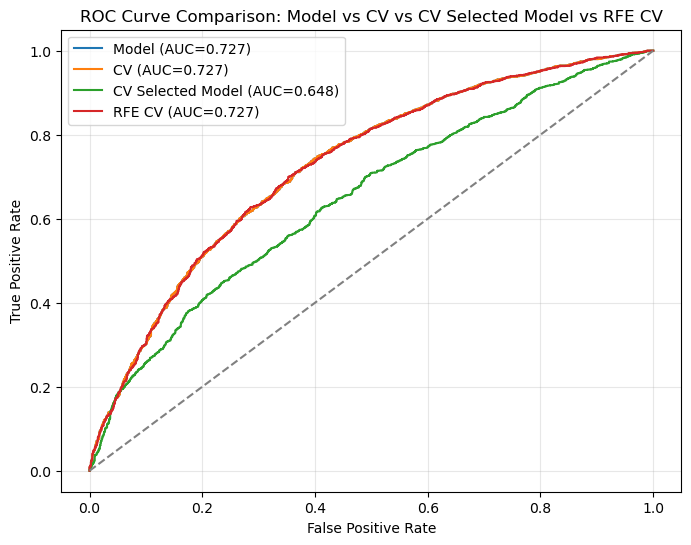

In [91]:
# Task 2.3 ROC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

model_prob = model_copy.predict_proba(X_test_copy)[:, 1]
cv_prob = cv.predict_proba(X_test_copy)[:, 1]
cv_sel_model_prob = cv_sel_model.predict_proba(X_test_sel_model)[:, 1]
rfe_cv_prob = rfe_cv.predict_proba(X_test_sel)[:, 1]

fpr_model, tpr_model, _ = roc_curve(y_test_copy, model_prob)
fpr_cv, tpr_cv, _ = roc_curve(y_test_copy, cv_prob)
fpr_cv_sel_model, tpr_cv_sel_model, _ = roc_curve(y_test_copy, cv_sel_model_prob)
fpr_rfe_cv, tpr_rfe_cv, _ = roc_curve(y_test_copy, rfe_cv_prob)

auc_model = roc_auc_score(y_test_copy, model_prob)
auc_cv = roc_auc_score(y_test_copy, cv_prob)
auc_cv_sel_model = roc_auc_score(y_test_copy, cv_sel_model_prob)
auc_rfe_cv = roc_auc_score(y_test_copy, rfe_cv_prob)

print("Model AUC:", auc_model)
print("CV AUC:", auc_cv)
print("CV Selected Model AUC:", auc_cv_sel_model)
print("RFE CV AUC:", auc_rfe_cv)

plt.figure(figsize=(8,6))

plt.plot(fpr_model, tpr_model,
         label=f"Model (AUC={auc_model:.3f})")

plt.plot(fpr_cv, tpr_cv,
         label=f"CV (AUC={auc_cv:.3f})")

plt.plot(fpr_cv_sel_model, tpr_cv_sel_model,
         label=f"CV Selected Model (AUC={auc_cv_sel_model:.3f})")

plt.plot(fpr_rfe_cv, tpr_rfe_cv,
         label=f"RFE CV (AUC={auc_rfe_cv:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Model vs CV vs CV Selected Model vs RFE CV")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Task 4 Neural Networks

Two multi-layer-perceptron classifiers for `is_accepted`, both tuned with `GridSearchCV`:

4.2 neural network on all features
4.3 neural network on the reduced feature set chosen by the best Task 2 decision tree
4.1 / 4.4 extra preprocessing, and ROC curves for both models

In [92]:
import warnings
warnings.filterwarnings('ignore')   

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('dataset_ifn580_262_v1.csv')

df = df.drop(columns=['car'])                                  
df['temperature'] = df['temperature'].fillna(df['temperature'].median())
for col in ['Bar', 'CoffeeHouse', 'CarryAway',
            'RestaurantLessThan20', 'Restaurant20To50']:
    df[col] = df[col].fillna(df[col].mode()[0])

df['age'] = df['age'].map({'below21':0,'21':1,'26':2,'31':3,'36':4,'41':5,'46':6,'50plus':7})
df['time'] = df['time'].map({'7AM':0,'10AM':1,'2PM':2,'6PM':3,'10PM':4})
df['income'] = df['income'].map({'Less than $12500':0,'$12500 - $24999':1,'$25000 - $37499':2,
                                 '$37500 - $49999':3,'$50000 - $62499':4,'$62500 - $74999':5,
                                 '$75000 - $87499':6,'$87500 - $99999':7,'$100000 or More':8})
df['education'] = df['education'].map({'Some High School':0,'High School Graduate':1,
                                      'Some college - no degree':2,'Associates degree':3,
                                      'Bachelors degree':4,
                                      'Graduate degree (Masters or Doctorate)':5})
freq_map = {'never':0,'less1':1,'1~3':2,'4~8':3,'gt8':4}
for col in ['Bar','CoffeeHouse','CarryAway','RestaurantLessThan20','Restaurant20To50']:
    df[col] = df[col].map(freq_map)
df['expiration'] = df['expiration'].map({'2h':0,'1d':1})
df['gender'] = df['gender'].map({'Female':0,'Male':1})

df = pd.concat([df, pd.get_dummies(df['destination'], prefix='destination', dtype=int)], axis=1)
df = df.drop(columns=['destination'])
nominal_columns = ['passanger','weather','coupon','maritalStatus','occupation']
df = pd.concat([df, pd.get_dummies(df[nominal_columns], prefix=nominal_columns, dtype=int)], axis=1)
df = df.drop(columns=nominal_columns)

df = df.drop(columns=['direction_opp'])           

print("processed shape:", df.shape, "| missing:", int(df.isnull().sum().sum()))

processed shape: (12684, 63) | missing: 0


In [93]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['is_accepted'])
y = df['is_accepted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

feature_names = X.columns
print("train:", X_train.shape, " test:", X_test.shape)

train: (8878, 62)  test: (3806, 62)


## 4.1 Additional processing required for the neural network

On top of the shared Task 1 preprocessing (numeric encoding, missing-value imputation,
one-hot encoding, correlation-based removal), a neural network needs:

Feature standardisation: every input is rescaled to mean 0 / standard deviation 1
  with `StandardScaler`, fitted on the training set only and then applied to both sets.
  The MLP is trained by gradient descent, which is scale-sensitive: without this, wide-range
  inputs such as `income` (0–8) or `time` (0–4) would dominate the weight updates and the
  network would train poorly. (This is the same requirement as the logistic-regression model
  in Task 3.)
A raised iteration cap: `max_iter` is set to 1000 so the Adam optimiser has enough
  iterations to converge (the sklearn default of 200 is far too low and stops with a convergence warning).

In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train, y_train)
X_test_scaled = scaler.transform(X_test)

print("before scaling  -> first row min/max:",
      round(X_train.values[0].min(), 2), round(X_train.values[0].max(), 2))
print("after  scaling  -> column means ~0:",
      np.round(X_train_scaled.mean(axis=0)[:5], 3),
      " column stds ~1:", np.round(X_train_scaled.std(axis=0)[:5], 3))

before scaling  -> first row min/max: 0.0 55.0
after  scaling  -> column means ~0: [ 0. -0. -0. -0. -0.]  column stds ~1: [1. 1. 1. 1. 1.]


## 4.2 Neural network tuned with GridSearchCV

Fixed parameters (and why):

| Parameter | Value | Reason |
|---|---|---|
| `activation` | `relu` | default in sklearn; trains fast and avoids vanishing gradients |
| `solver` | `adam` | adaptive gradient descent, the standard choice for this size of data |
| `max_iter` | `1000` | high enough for Adam to fully converge on this dataset |
| `random_state` | `42` | reproducibility, consistent with Tasks 2 and 3 |

Searched hyperparameters:

 `hidden_layer_sizes` ∈ {(5,), (10,), (20,), (40,), (n_features,)} – one hidden layer,
  from very small up to one neuron per input. Week 6 guidance is to keep the hidden layer
  between the output size (1) and the input size, and the simpler models in Tasks 2–3
  generalised better on this data, so small sizes are included.
 `alpha` ∈ {1e-4, 1e-3, 1e-2, 1e-1} – L2 regularisation strength (default 1e-4), spanning
  two orders of magnitude to control over-fitting.

`cv=5` (5-fold cross-validation), matching the Task 2 grid search.

In [95]:
import time
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

n_features = X_train_scaled.shape[1]

mlp_param_grid = {
    'hidden_layer_sizes': [(5,), (10,), (20,), (40,), (n_features,)],
    'alpha': [1e-4, 1e-3, 1e-2, 1e-1],
}

mlp_base = MLPClassifier(activation='relu', solver='adam',
                         max_iter=1000, random_state=42)

start = time.time()
mlp_grid = GridSearchCV(mlp_base, param_grid=mlp_param_grid,
                        cv=5, scoring='accuracy', n_jobs=-1)
mlp_grid.fit(X_train_scaled, y_train)
mlp_grid_time = time.time() - start

mlp_best = mlp_grid.best_estimator_
print("Best parameters:", mlp_grid.best_params_)
print("Best CV score  :", round(mlp_grid.best_score_, 4))
print(f"GridSearchCV time: {mlp_grid_time:.1f} s")

Best parameters: {'alpha': 0.01, 'hidden_layer_sizes': (20,)}
Best CV score  : 0.7057
GridSearchCV time: 27.8 s


### 4.2b Classification accuracy

In [96]:
mlp_train_acc = mlp_best.score(X_train_scaled, y_train)
mlp_test_acc = mlp_best.score(X_test_scaled, y_test)
print("Training accuracy:", round(mlp_train_acc, 4))
print("Testing  accuracy:", round(mlp_test_acc, 4))
print()
print(classification_report(y_test, mlp_best.predict(X_test_scaled)))

Training accuracy: 0.8078
Testing  accuracy: 0.7099

              precision    recall  f1-score   support

           0       0.68      0.62      0.65      1649
           1       0.73      0.78      0.75      2157

    accuracy                           0.71      3806
   macro avg       0.70      0.70      0.70      3806
weighted avg       0.71      0.71      0.71      3806



### 4.2c Did the training process converge?

Iterations run (n_iter_): 450 of max_iter = 1000
Final training loss     : 0.4262
Converged (stopped on loss plateau, not the iteration cap): True


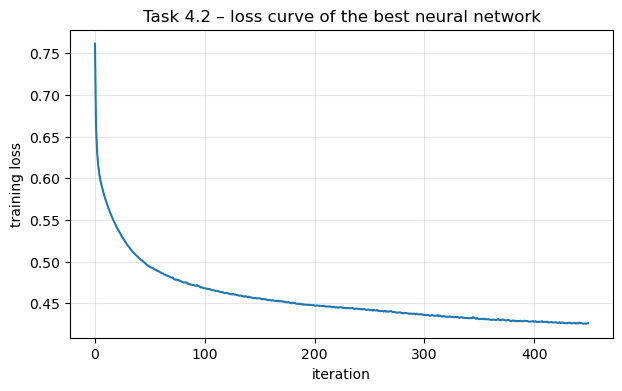

In [97]:
print("Iterations run (n_iter_):", mlp_best.n_iter_, "of max_iter =", 1000)
print("Final training loss     :", round(mlp_best.loss_, 4))
converged = mlp_best.n_iter_ < 1000
print("Converged (stopped on loss plateau, not the iteration cap):", converged)

plt.figure(figsize=(7, 4))
plt.plot(mlp_best.loss_curve_)
plt.xlabel("iteration"); plt.ylabel("training loss")
plt.title("Task 4.2 – loss curve of the best neural network")
plt.grid(alpha=0.3); plt.show()

### 4.2d Sign of over-fitting?

In [98]:
print("Train accuracy :", round(mlp_train_acc, 4))
print("Test  accuracy :", round(mlp_test_acc, 4))
print("Train - test gap:", round(mlp_train_acc - mlp_test_acc, 4))

Train accuracy : 0.8078
Test  accuracy : 0.7099
Train - test gap: 0.0979


## 4.3 Neural network on the decision-tree-reduced feature set

The reduced feature set is chosen by the best Task 2 decision tree
(`criterion='entropy'`, `max_depth=10`, `min_samples_leaf=1`, `min_samples_split=20`).
`SelectFromModel` keeps the features whose tree importance is above the mean; the neural
network is then re-tuned with `GridSearchCV` on that smaller input.

In [99]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel

dt_tuned = DecisionTreeClassifier(criterion='entropy', max_depth=10,
                                  min_samples_leaf=1, min_samples_split=20,
                                  random_state=42)
dt_tuned.fit(X_train, y_train)

selector = SelectFromModel(dt_tuned, prefit=True, threshold='mean')
X_train_sel = selector.transform(X_train_scaled)
X_test_sel = selector.transform(X_test_scaled)

selected_features = list(feature_names[selector.get_support()])
print(f"features reduced: {X_train_scaled.shape[1]} -> {X_train_sel.shape[1]}")
print("network input variables:")
for f in selected_features:
    print("   ", f)

features reduced: 62 -> 16
network input variables:
    temperature
    time
    expiration
    age
    education
    income
    Bar
    CoffeeHouse
    CarryAway
    RestaurantLessThan20
    Restaurant20To50
    toCoupon_GEQ25min
    passanger_Friend(s)
    coupon_Carry out & Take away
    coupon_Coffee House
    coupon_Restaurant(<20)


### 4.3a Did feature selection favour the outcome, and how did the architecture change?

In [100]:
n_sel = X_train_sel.shape[1]
mlp_param_grid_sel = {
    'hidden_layer_sizes': [(3,), (5,), (7,), (n_sel,)],
    'alpha': [1e-4, 1e-3, 1e-2],
}

start = time.time()
mlp_grid_sel = GridSearchCV(
    MLPClassifier(activation='relu', solver='adam', max_iter=1000, random_state=42),
    param_grid=mlp_param_grid_sel, cv=5, scoring='accuracy', n_jobs=-1)
mlp_grid_sel.fit(X_train_sel, y_train)
mlp_sel_time = time.time() - start
mlp_sel = mlp_grid_sel.best_estimator_

print("Full-feature best architecture   :", mlp_grid.best_params_['hidden_layer_sizes'],
      " alpha =", mlp_grid.best_params_['alpha'])
print("Reduced-feature best architecture :", mlp_grid_sel.best_params_['hidden_layer_sizes'],
      " alpha =", mlp_grid_sel.best_params_['alpha'])
print(f"GridSearchCV time: {mlp_sel_time:.1f} s  (vs {mlp_grid_time:.1f} s on all features)")

Full-feature best architecture   : (20,)  alpha = 0.01
Reduced-feature best architecture : (7,)  alpha = 0.001
GridSearchCV time: 4.2 s  (vs 27.8 s on all features)


### 4.3b Classification accuracy

In [101]:
mlp_sel_train_acc = mlp_sel.score(X_train_sel, y_train)
mlp_sel_test_acc = mlp_sel.score(X_test_sel, y_test)
print("Reduced NN training accuracy:", round(mlp_sel_train_acc, 4))
print("Reduced NN testing  accuracy:", round(mlp_sel_test_acc, 4))
print()
print(classification_report(y_test, mlp_sel.predict(X_test_sel)))

Reduced NN training accuracy: 0.7049
Reduced NN testing  accuracy: 0.6989

              precision    recall  f1-score   support

           0       0.67      0.59      0.63      1649
           1       0.72      0.78      0.75      2157

    accuracy                           0.70      3806
   macro avg       0.69      0.69      0.69      3806
weighted avg       0.70      0.70      0.70      3806



### 4.3c Iterations that kept improving before the final non-improving period

Total iterations run (n_iter_)      : 154
n_iter_no_change (patience)         : 10
Iteration with the lowest loss      : 154
=> training loss reached its minimum at iteration 154; the optimiser then
   needs 10 consecutive non-improving iterations to trigger the stop,
   so the improving phase is roughly the first 154 iterations (n_iter_ - patience = 144).


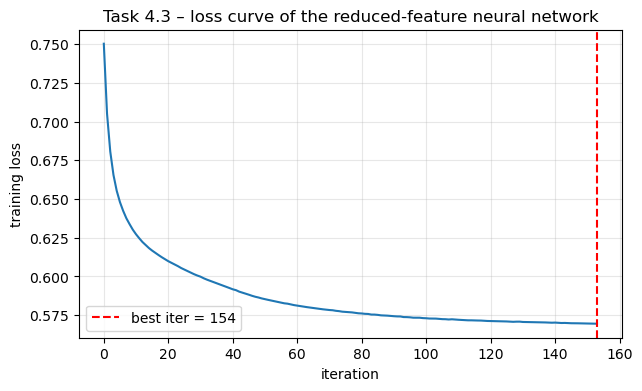

In [102]:
loss_curve = mlp_sel.loss_curve_
best_iter = int(np.argmin(loss_curve)) + 1
print("Total iterations run (n_iter_)      :", mlp_sel.n_iter_)
print("n_iter_no_change (patience)         :", mlp_sel.n_iter_no_change)
print("Iteration with the lowest loss      :", best_iter)
print(f"=> training loss reached its minimum at iteration {best_iter}; the optimiser then")
print(f"   needs {mlp_sel.n_iter_no_change} consecutive non-improving iterations to trigger the stop,")
print(f"   so the improving phase is roughly the first {best_iter} iterations "
      f"(n_iter_ - patience = {mlp_sel.n_iter_ - mlp_sel.n_iter_no_change}).")

plt.figure(figsize=(7, 4))
plt.plot(loss_curve)
plt.axvline(best_iter - 1, color='red', linestyle='--', label=f'best iter = {best_iter}')
plt.xlabel("iteration"); plt.ylabel("training loss")
plt.title("Task 4.3 – loss curve of the reduced-feature neural network")
plt.legend(); plt.grid(alpha=0.3); plt.show()

### 4.3d Over-fitting and convergence

In [103]:
print("Reduced NN train accuracy :", round(mlp_sel_train_acc, 4))
print("Reduced NN test  accuracy :", round(mlp_sel_test_acc, 4))
print("Train - test gap          :", round(mlp_sel_train_acc - mlp_sel_test_acc, 4))
print("Converged (n_iter_ < 1000) :", mlp_sel.n_iter_ < 1000, f"(n_iter_ = {mlp_sel.n_iter_})")

Reduced NN train accuracy : 0.7049
Reduced NN test  accuracy : 0.6989
Train - test gap          : 0.006
Converged (n_iter_ < 1000) : True (n_iter_ = 154)


## 4.4 ROC curves for both neural-network models

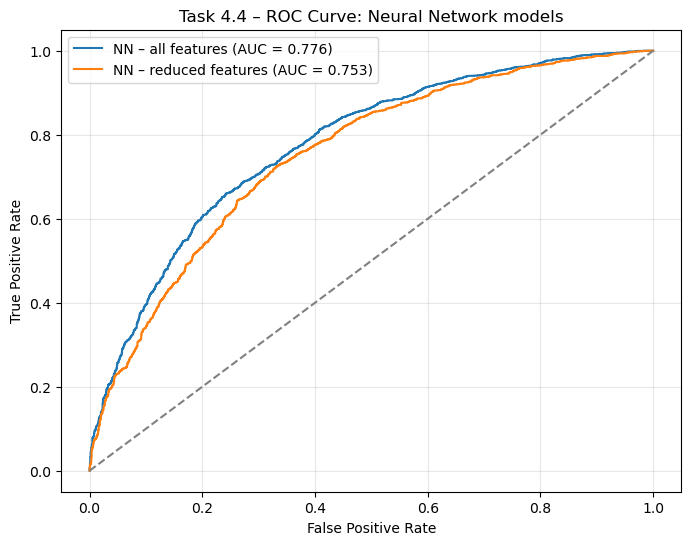

AUC – all features    : 0.7757
AUC – reduced features: 0.7528


In [104]:
from sklearn.metrics import roc_curve, roc_auc_score

proba_full = mlp_best.predict_proba(X_test_scaled)[:, 1]
proba_sel = mlp_sel.predict_proba(X_test_sel)[:, 1]

auc_full = roc_auc_score(y_test, proba_full)
auc_sel = roc_auc_score(y_test, proba_sel)
fpr_full, tpr_full, _ = roc_curve(y_test, proba_full)
fpr_sel, tpr_sel, _ = roc_curve(y_test, proba_sel)

plt.figure(figsize=(8, 6))
plt.plot(fpr_full, tpr_full, label=f"NN – all features (AUC = {auc_full:.3f})")
plt.plot(fpr_sel, tpr_sel, label=f"NN – reduced features (AUC = {auc_sel:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Task 4.4 – ROC Curve: Neural Network models")
plt.legend(); plt.grid(alpha=0.3); plt.show()

print("AUC – all features    :", round(auc_full, 4))
print("AUC – reduced features:", round(auc_sel, 4))

## Summary (Task 4)


In [105]:
import pandas as pd
summary = pd.DataFrame({
    "Model": ["NN – all features (4.2)", "NN – reduced features (4.3)"],
    "Train accuracy": [round(mlp_train_acc, 4), round(mlp_sel_train_acc, 4)],
    "Test accuracy": [round(mlp_test_acc, 4), round(mlp_sel_test_acc, 4)],
    "Train-test gap": [round(mlp_train_acc - mlp_test_acc, 4),
                       round(mlp_sel_train_acc - mlp_sel_test_acc, 4)],
    "Test AUC": [round(auc_full, 4), round(auc_sel, 4)],
    "n_iter_": [mlp_best.n_iter_, mlp_sel.n_iter_],
    "hidden_layer_sizes": [mlp_grid.best_params_['hidden_layer_sizes'],
                           mlp_grid_sel.best_params_['hidden_layer_sizes']],
})
summary

,Model,Train accuracy,Test accuracy,Train-test gap,Test AUC,n_iter_,hidden_layer_sizes
0,NN – all features (4.2),0.8078,0.7099,0.0979,0.7757,450,"(20,)"
1,NN – reduced features (4.3),0.7049,0.6989,0.0060,0.7528,154,"(7,)"
